In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import pandas as pd
pd.set_option("display.max_colwidth", None)

import transformers

from src.data_loader import load_train_reviews

reviews = load_train_reviews()

d:\Quera\Exercises\amazon-review-sentiment-analysis\src\data_loader.py:17: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Users\fam-01\.conda\envs\quera\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fam-01\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [5]:
sample_reviews = reviews.sample(n=50000, random_state=42).copy()

sample_reviews["token_count"] = sample_reviews["reviewText"].apply(
    lambda text: len(
        tokenizer.encode(str(text), add_special_tokens=True, truncation=False)
    )
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1496 > 512). Running this sequence through the model will result in indexing errors


In [6]:
sample_reviews["token_count"].describe()

count    50000.000000
mean       148.373580
std        173.402072
min         35.000000
25%         66.000000
50%         96.000000
75%        164.000000
max       6424.000000
Name: token_count, dtype: float64

In [7]:
sample_reviews["token_count"].quantile([0.90, 0.95, 0.99, 0.995])

0.900     289.000
0.950     412.000
0.990     834.000
0.995    1067.005
Name: token_count, dtype: float64

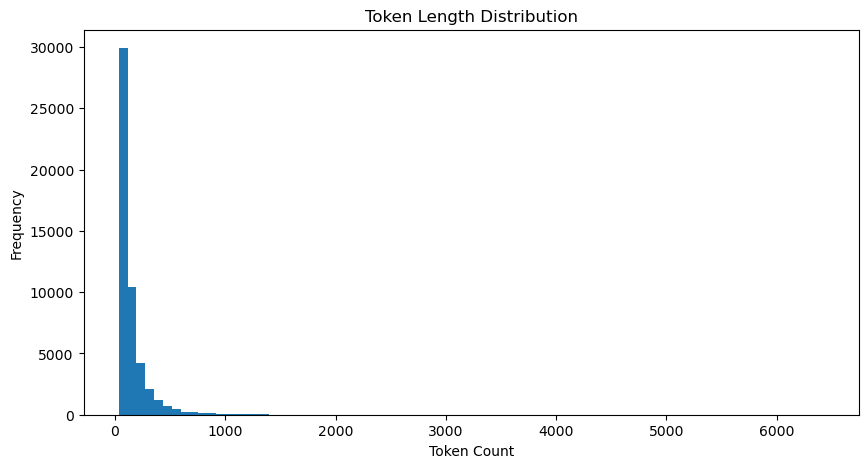

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(sample_reviews["token_count"], bins=80)

plt.xlabel("Token Count")

plt.ylabel("Frequency")

plt.title("Token Length Distribution")

plt.show()

In [9]:
def truncation_ratio(length):

    return (sample_reviews["token_count"] > length).mean() * 100


for max_len in [64, 128, 256, 384, 512]:

    print(max_len, truncation_ratio(max_len))

64 76.422
128 34.756
256 12.312
384 5.8340000000000005
512 3.114


token_count  \
614881         6424   
616557         5839   
634948         5107   
676140         4931   
492717         4466   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
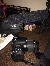

In [10]:
sample_reviews.sort_values("token_count", ascending=False)[
    ["token_count", "reviewText"]
].head(5)